### Testing File

In [1]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

# Initialize the model, using Haiku for now, but should prob change to sonnet once things are working

model = init_chat_model("claude-haiku-4-5-20251001")


/home/ruben/CLBuilder/agentic_CL_builder/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [ ]:
# Define tools for the researcher node

from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
from langchain_core.tools import Tool

from langchain_tavily import TavilySearch
from crawl4ai import AsyncWebCrawler

from langchain_core.tools import tool

tavily_tool = TavilySearch(
    max_results=3,
)


@tool
async def web_crawler_tool(url: str) -> str:
    """
    Crawls a website and returns its clean markdown content. 
    Use this for extracting detailed information from job postings or company pages.
    """
    async with AsyncWebCrawler() as crawler:
        # arun fetches the page and converts it to LLM-ready markdown
        result = await crawler.arun(url=url)
        
        if result.success:
            return result.markdown
        else:
            return f"Failed to crawl {url}: {result.error_message}"




# setup the Context Matcher



# Augment the LLM with tools
tools = [tavily_tool, web_crawler_tool]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

In [3]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator
from typing import List

# Build state that will be used to store everything


class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]
    llm_calls: int
    job_url: str
    job_desc: str
    company_research: str
    resume_context: List[str]
    writing_sample: str
    selected_experiences: List[str]
    draft_letter: str
    critique: str
    final_pdf_path: str
    iteration_count: int

In [4]:
from langchain.messages import SystemMessage, ToolMessage


#main agent

def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""
    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="""You are a helpful researcher tasked with using your tools to take in a given request, and 
                        perform the necessary tool calls to fill out the company research and job description fields in the State. 
                        Take the URL that is given to you,and perform a Crawl scrape on it, which gets saved to job_desc. Based on 
                        whatever company that job description is for, then perform a Tavily search to find out general company values,
                        mission statements, and beliefs that characterize the work and style of that company, this will then be saved 
                        into company_research. You do not need to know the specific information extracted from either tool, that is
                        handled and saved to the state by the tool itself. Proceed once both tasks are complete. Do not summarize or
                        discuss what was extracted, simply call the necessary tools, and move on."""
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }



#tool node with tool calls

async def tool_node(state: AgentState):
    """Unified tool node that extracts and summarizes results directly into the state."""
    last_message = state["messages"][-1]
    tool_messages = []
    
    # Use local variables to build the update dictionary
    updated_company_research = state.get("company_research", "")
    updated_job_desc = state.get("job_desc", "")
    updated_job_url = state.get("job_url", "")

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        
        # 1. HANDLE COMPANY RESEARCH (TAVILY)
        if "tavily" in tool_name.lower():
            query = tool_call["args"].get("query", "")
            raw_result = await tavily_tool.ainvoke({"query": query})
            
            summary_prompt = f"Summarize the company values and mission from this research in 3-5 sentences. CONTENT:{raw_result}"
            summary = await model.ainvoke(summary_prompt)
            
            updated_company_research = summary.content
            tool_messages.append(ToolMessage(
                content="Company research summarized and saved.", 
                tool_call_id=tool_call["id"]
            ))

        # 2. HANDLE JOB DESCRIPTION (CRAWL4AI)
        elif tool_name == "web_crawler_tool":

            url = tool_call["args"].get("url", "")
            raw_markdown = await web_crawler_tool.ainvoke({"url": url})
            
            summary_prompt = f"""
                Extract only the job responsibilities, requirements, and benefits from the following markdown.
                Ignore navigation menus, footer links, and application form fields (dropdowns, questions).
                
                CONTENT: {raw_markdown}
                """
            summary = await model.ainvoke(summary_prompt)
            
            updated_job_desc = summary.content
            updated_job_url = url
            tool_messages.append(ToolMessage(
                content="Job description summarized and saved.", 
                tool_call_id=tool_call["id"]
            ))
            
        # 3. SAFETY FALLBACK (Prevents the 400 error)
        else:
            print("\n Entering Else Statement!")
            tool_messages.append(ToolMessage(
                content="Tool executed but result not summarized.", 
                tool_call_id=tool_call["id"]
            ))

    return {
        "company_research": updated_company_research,
        "job_desc": updated_job_desc,
        "job_url": updated_job_url,
        "messages": tool_messages
    }


In [5]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

#conditional function to determine which node to go to next

def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]

    if not last_message.tool_calls:
        return END

    destinations = []
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        if tool_name == "web_crawler_tool":
            destinations.append("research_job")
        elif tool_name in ["tavily_search_results_json", "tavily_tool"]:
            destinations.append("company_research")
            
    return destinations if destinations else END


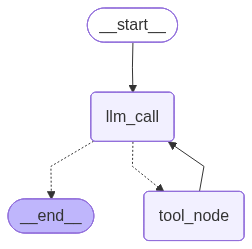

In [6]:
from langgraph.graph import StateGraph, START, END

agent_builder = StateGraph(AgentState)
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)  # Single unified node

def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        return END
    return "tool_node"

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

agent = agent_builder.compile()

#display graph for debugging purposes/flow

from IPython.display import Image, display
try:
    display(Image(agent.get_graph(xray=True).draw_mermaid_png()))
except:
    pass


In [14]:
# Invoke/Attempt flow


from langchain.messages import HumanMessage

request = [HumanMessage(content="Scrape the listing from this website: https://scale.com/careers/4655050005. Also extract the company information of that listing")]

# messages = [HumanMessage(content="Search the web for SpaceX culture, and broad company missions statements")]

messages = await agent.ainvoke({"messages": request})
for m in messages["messages"]:
    m.pretty_print()

[INIT].... → Crawl4AI 0.8.0 

[FETCH]... ↓ https://scale.com/careers/4655050005                                                                 |
✓ | ⏱: 1.36s 

[SCRAPE].. ◆ https://scale.com/careers/4655050005                                                                 |
✓ | ⏱: 0.03s 

[COMPLETE] ● https://scale.com/careers/4655050005                                                                 |
✓ | ⏱: 1.39s 

================================ Human Message =================================

Scrape the listing from this website: https://scale.com/careers/4655050005. Also extract the company information of that listing
================================== Ai Message ==================================

[{'text': "I'll scrape the job listing and extract the company information for you.", 'type': 'text'}, {'id': 'toolu_01Fn12nM5mdiJBFuy26mz9M9', 'caller': {'type': 'direct'}, 'input': {'url': 'https://scale.com/careers/4655050005'}, 'name': 'web_crawler_tool', 'type': 'tool_use'}, {'id': 'toolu_013Ta4H3rv7ugRmvaXENgt4z', 'caller': {'type': 'direct'}, 'input': {'query': 'Scale AI company values mission statement beliefs', 'search_depth': 'advanced'}, 'name': 'tavily_search', 'type': 'tool_use'}]
Tool Calls:
  web_crawler_tool (toolu_01Fn12nM5mdiJBFuy26mz9M9)
 Call ID: toolu_01Fn12nM5mdiJBFuy26mz9M9
  Args:
    url: https://scale.com/careers/4655050005
  tavily_search (toolu_013Ta4H3rv7ugRmvaXENgt4z)


In [15]:
#evaluate output

import textwrap


print(messages["llm_calls"])

# print(textwrap.fill(messages["job_desc"], width=40))

print(textwrap.fill(messages["company_research"], width=40))


2
# Scale AI Company Values and Mission
Summary  Scale AI's mission is to
**develop reliable AI systems for the
world's most important decisions** by
providing high-quality data and full-
stack technologies that power leading AI
models. The company believes that
**quality compounds and scales with
precision, care, and intentionality**,
applying this principle across all
strategic and operational decisions.
Scale operates through three key
pillars: the Generative AI Platform for
building and controlling AI agents, the
Data Engine for curating high-quality
datasets, and the Safety, Evaluations,
and Alignment Lab (SEAL) for rigorous
model testing. The company is committed
to supporting both its team members and
customers, offering a flexible
environment where talent is valued while
helping enterprises and governments
deploy trustworthy AI applications with
measurable impact.
